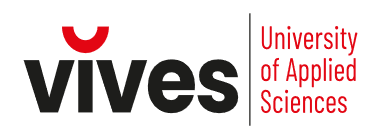<br>


**MACHINE LEARNING FUNDAMENTALS**<br>
APPLIED COMPUTER SCIENCE<br>
Specialization in Artificial Intelligence<br>
Andy Louwyck

---



---



# **EVALUATION METRICS FOR CLASSIFICATION: THEORY**

## Introduction

In mathematics, a **metric** is a generalization of the normal concept of distance. In machine learning and data science, we will apply all kinds of metrics to objectively evaluate models, which we call **evaluation metrics**. They are used to assess the quality of models, and consequently, they are applied in the evaluation phase after modeling. In practice, this means that we apply them to evaluate models on their performance. So, they are useful for *validating* and *testing* the models. In this way, we can compare different models in a more objective way.

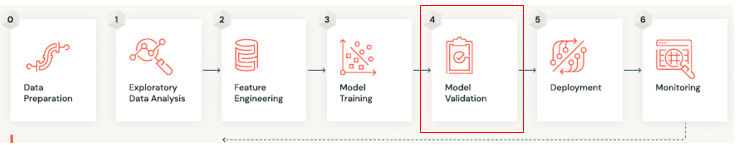

We have already studied a few machine learning models in detail:
- linear regression
- polynomial regression
- perceptron
- logistic regression

The performance of **linear and polynomial regression** models is evaluated by calculating metrics such as MAE, MSE, RMSE, and R².

The **perceptron and logistic regression** models are used for **classification**. It is important that we also apply the right techniques for evaluating and comparing the performance of classification models.

A frequently used - and often misused - metric to estimate the performance of a classification model is **accuracy**. Although this evaluation metric is a very important measure, which is easy for us humans to understand, the performance of a classification model should not only be evaluated with this metric. In a next section we will see why.

It is also important to distinguish between **binary and multi-class classification**, because some metrics, such as the ROC curve, can only be applied when there are only 2 classes. If there are multiple classes, we can adjust this by applying the principle of *one versus the rest*. That is, we compare one class against the rest. Suppose we have 3 classes: dogs, cats and rabbits. Then we compare dog versus no dog, cat versus no cat, and rabbit versus no rabbit. In this way, we simplify the multinomial classification to 3 binary classifications.

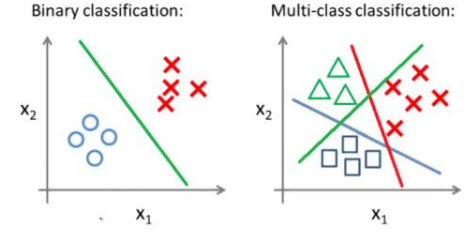

## Example datasets

We first introduce two fictional datasets that we will use to demonstrate the metrics in this topic.

**Covid dataset**

We have a dataset with data on 1000 patients. Of those 1000 patients, we know that 10 have contracted corona and are therefore sick. 990 patients are healthy. The labels in the dataset are 'sick' for people who have corona and 'healthy' for people who are not infected.

**Email dataset**

We have a dataset with 100 emails. There are 40 emails labeled as spam; the rest have the label ham, which means these emails are desired.

## Accuracy

**Definition**

The accuracy of a model is a metric to express *how often a model makes a correct prediction*:

> $accuracy = \frac{\#\textrm{correct predictions}}{\textrm{total number of predictions}}$

For example: if we have a corona test that makes 875 correct predictions for our patients from the medical dataset, then the accuracy of the underlying model is:

> $accuracy = \frac{\#\textrm{correct predictions}}{\textrm{total number of predictions}} = \frac{875}{1000} = 0.875 = 87.5\%$

For example: if we have a spam filter that places 95 emails from our email dataset in the correct folders, then the accuracy of the underlying model is:

> $accuracy = \frac{\#\textrm{correct predictions}}{\textrm{total number of predictions}} = \frac{95}{100} = 0.95 = 95\%$

**Problem with accuracy**

Let's use accuracy in the context of the covid dataset above. Before we can make a statement about accuracy, we obviously need a model. Suppose we have designed a new COVID-19 test. It takes only 10 seconds to perform the test and know the result. No medical intervention is required; we can quickly make a statement based on the symptoms alone. And wonder of wonders, the accuracy of the test is 99%!

Question: Can you come up with such a test yourself?

For this, implement the function `predict_covid(patient_data)` which returns a boolean indicating whether or not the patient has COVID-19.

In [1]:
def predict_covid(patient_data):
    return False  # always predict the patient is healthy!

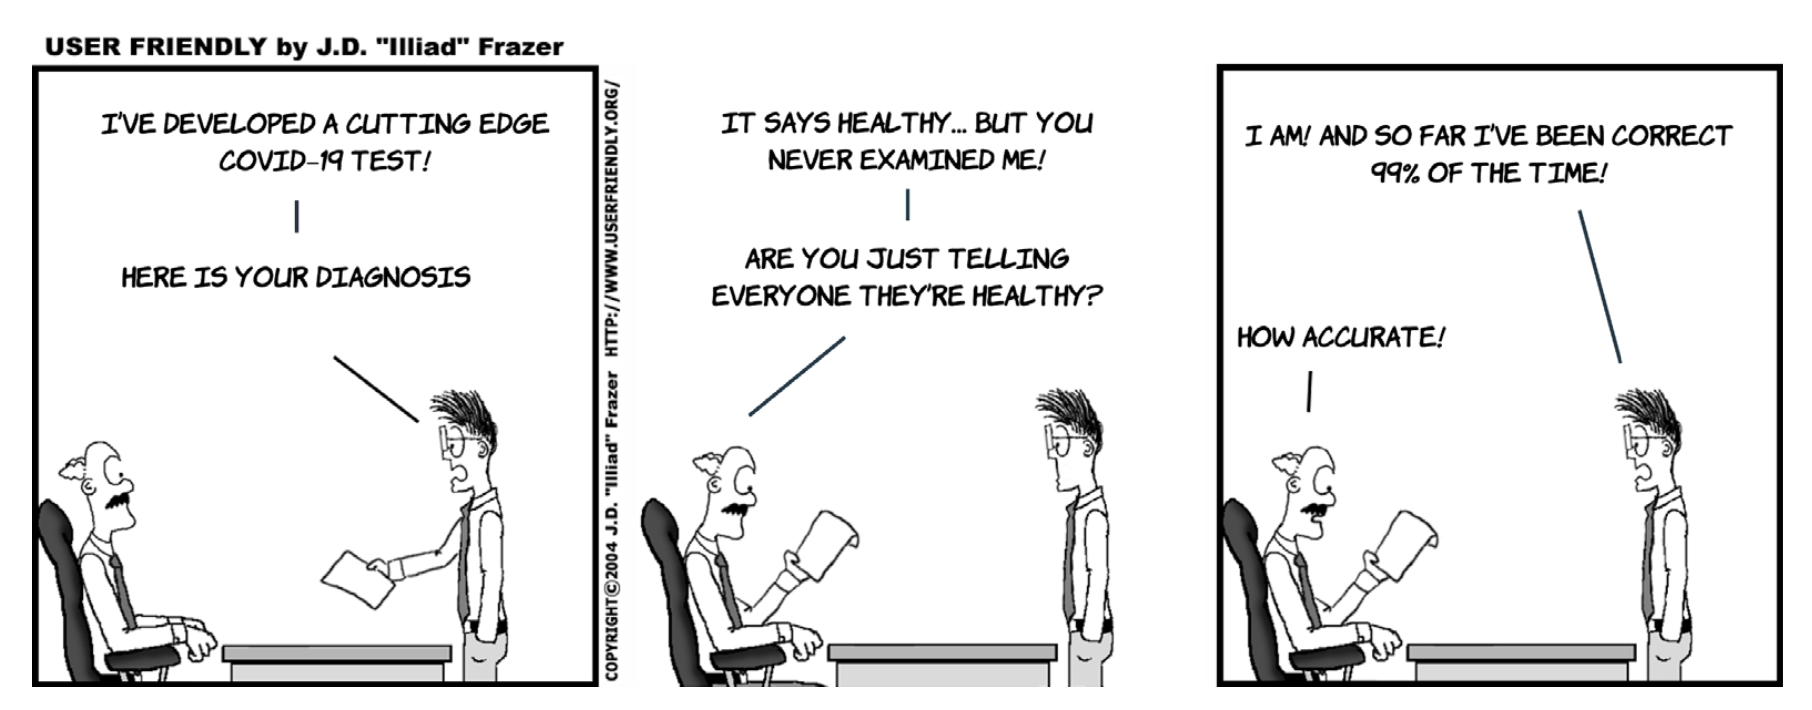

So if you predict for every patient that they are not sick, then you have an accuracy of 990/1000 = 99% on the given set! And yet that model is worthless. The model only makes 10 wrong predictions, but the dataset is strongly *unbalanced* so that those errors are not *charged heavily enough* by the accuracy metric. So we will need other metrics that correctly assess wrong predictions!

## Types of wrong predictions

In this topic we will only discuss binary classifiers, so a classifier predicts whether a data point belongs to a certain category or not.

Concretely, the data point gets a **positive** label for a positive prediction, so if the data point belongs to the category that is the focus. For a negative prediction, the data point gets a **negative** label.

In both the medical and e-mail datasets, we assume that we have a classifier to predict whether a person is sick or an e-mail is spam, respectively.

In the medical dataset:
- a person that we predict is sick, and therefore gets the label 'sick', gets a positive or `True` label.
- a person that we predict is healthy, and therefore gets the label 'healthy', gets a negative or `False` label.

In the email dataset:
- an email that we predict contains 'spam', gets a positive or `True` label.
- an email that we predict does not contain spam, and therefore is 'ham', gets a negative `False` label.

A **binary classifier** can now make **two possible mistakes**:
- A data point that we know is negative can be wrongly labeled positive. These are called **false positives (FP)**. For example:
  - a healthy person is predicted as sick;
  - a ham email is considered spam.
- A data point that we know is positive can be wrongly labeled negative. These are called **false negatives (FN)**. For example:
  - a sick person is predicted as healthy;
  - a spam email is considered ham;

Of course you also have:
- The **true positives (TP)**, for example:
  - sick people that are actually predicted as sick;
  - spam emails that are recognized as spam.
- The **true negatives (TN)**, for example:
  - healthy people that are actually predicted as healthy;
  - ham emails that are recognized as ham.


The figure below shows a graphical representation of models that are trained on our example datasets. On the left of the figure are the results of a model for the corona problem, on the right are results for the spam filter.


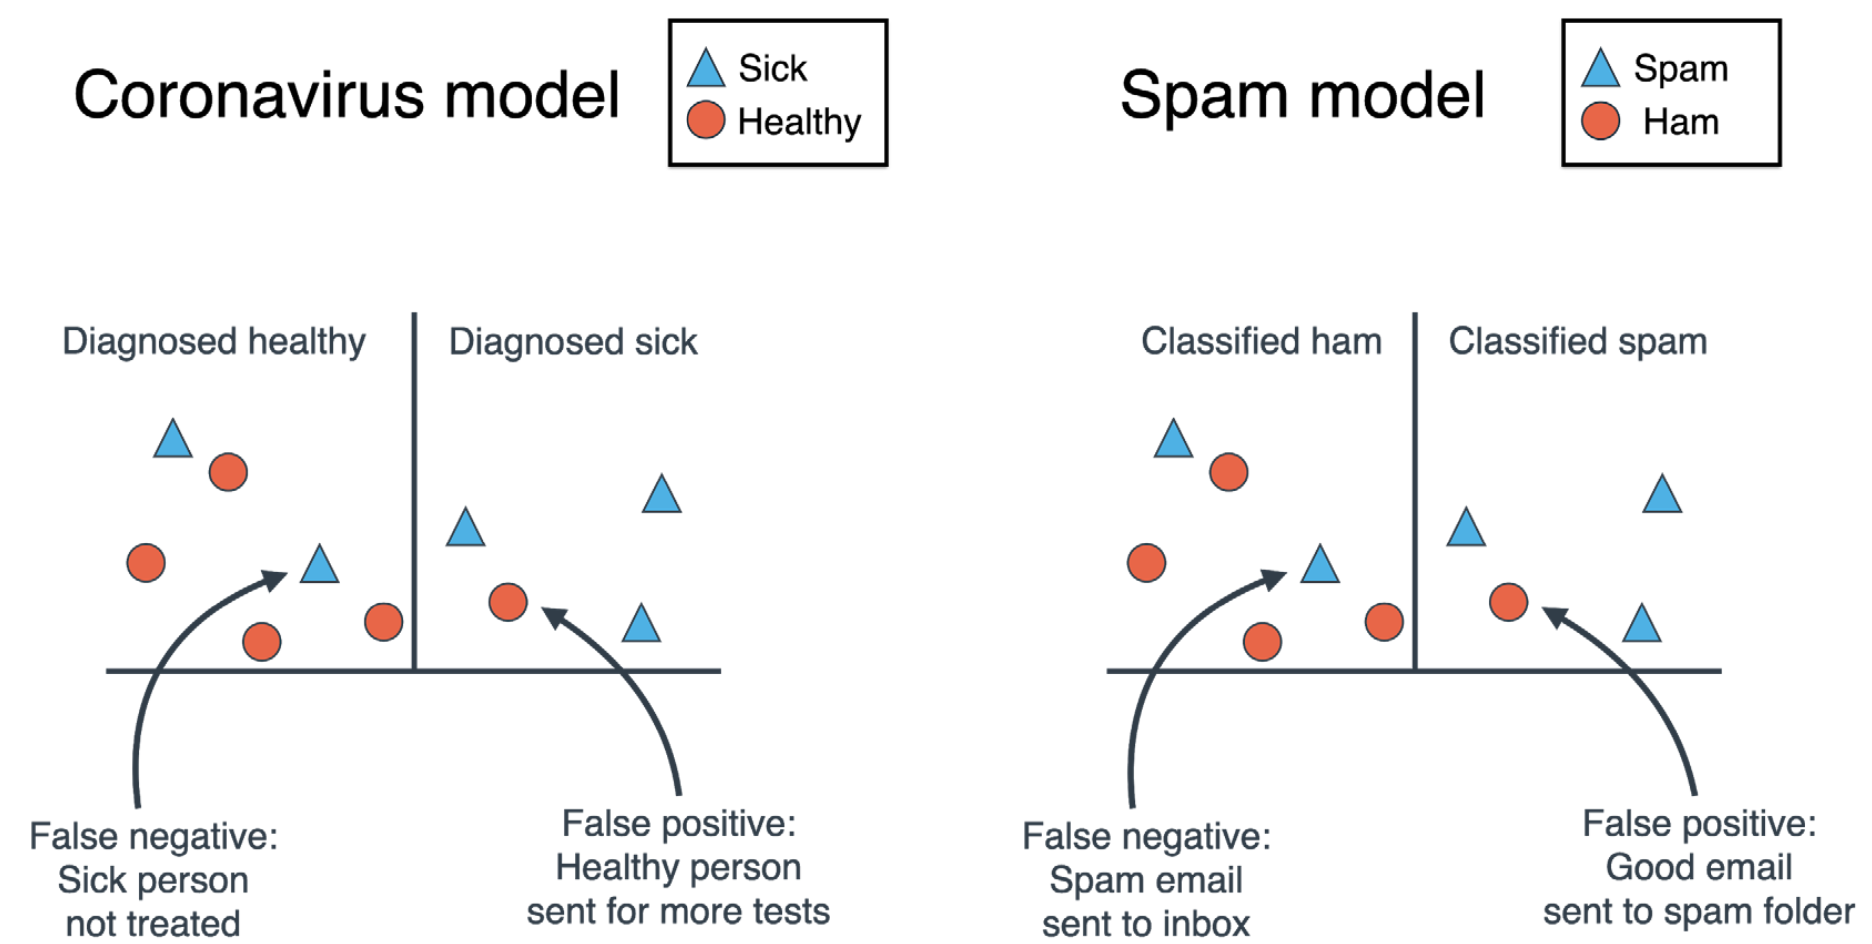

Both models have the following counts:
- 3 true positives
- 4 true negatives
- 1 false positive
- 2 false negatives

Although both models can present the same counts, there is still a difference in performance between the two models. We explain this difference by means of an analysis of the false positives and false negatives.

**Analysis of the corona test**

As we've discussed, a model can make two types of errors: false positives and false negatives. The problem with accuracy is that there is no trade-off between these two types. Depending on the application, the impact of a certain type of error can be greater than the other type.

If we have to allow errors, which type of error has the greatest impact in the case of the corona model? In other words, what is the 'worst' error you can make? A false positive or a false negative?

- false positive: this means that we label a perfectly healthy person as COVID-positive.
- false negative: this means that we label an infected person as perfectly healthy.

The latter is of course problematic, because the infected person does not go into quarantine, can suddenly become very ill, and can infect many other people. With this model, we therefore prefer false positives over false negatives!

**Spam filter analysis**

Suppose that when our spam filter detects an unwanted email, that email is automatically deleted.

Which type of error has the greatest impact? In other words, which error is the 'worst' to make?

- false negative: a spam email is not recognized, and therefore ends up in the inbox.
- false positive: a ham email is incorrectly recognized as spam and therefore ends up in the spam folder.

It is clear that we prefer a false negative here because a false positive can have a greater negative impact.

In this model, we prefer false negatives over false positives!

**Conclusion**

The two above applications and associated models therefore differ in preference for the type of error that is allowed. However, both models have the same accuracy!

We therefore need additional metrics to evaluate the performance of a classifier. But before we discuss these metrics, we first introduce a way to represent the 4 most important elements for these metrics, i.e. true positives, true negatives, false positives and false negatives, in a structured and clear way: the **confusion matrix**.

## Confusion matrix

In the previous section we introduced four important measures:
- *true positives* (TP)
- *true negatives* (TN)
- *false positives* (FP)
- *false negatives* (FN)

A confusion matrix is a table that summarizes these four measures. The figure below is an example. The rows represent the actual labels, the columns the predicted labels.

|  | Predicted positives | Predicted negatives | Total |
| --- | --- | --- | --- |
| Actual positives | number of true positives (TP)| number of false negatives (FN) | TP + FN
| Actual negatives | number of false positives (FP) | number of true negatives (TN) | FP+TN
| Total | TP+FP |FN+TN | TP + TN + FP + FN

Let's take the example of the bad corona test again. We had developed a test that predicts for every patient that they are not sick (negative!). However, we know that out of 1000 test subjects, 10 are actually sick. In summary, we get the table below:

| Coronavirus model 1 | Predicted sick | Predicted healthy | Total |
| --- | --- | --- | --- |
| Actually sick | 0 | 10 | 10
| Actually healthy | 0| 990 | 990
| Total | 0 | 1000 | 1000

We can already see here that this test is not ok because the first column consists of all zeros! We can now derive additional evaluation metrics from our confusion matrix that can detect these kinds of irregularities. We start with *recall and precision*.

## Recall and Precision

### Recall

First of all, we want a metric that focuses on the **false negatives**, i.e. identifies an excess of false negatives. For that, we use the **recall R**:

> $\textrm{recall} = \frac{\textrm{true positives}}{\textrm{true positives} + \textrm{false negatives}}$

Recall returns the percentage of actual positives that are predicted as such. Indeed, the denominator gives the number of samples that are actually labeled as positive, while the numerator is the number of samples that are correctly predicted as positive.

Think back to the case of the corona test. Ideally, we want to detect all sick people. So we don't want any false negatives. Recall is a metric that is suitable for evaluating this, because it effectively assigns a poor performance to the bad corona test.

If we apply that metric to the bad corona test, we indeed get:

> $\textrm{recall} = \frac{0}{0 + 10} = 0$

The value 0 indeed shows that in terms of false negatives, this test performs very poorly.

To illustrate, we give the results of a second corona test:

| Coronavirus model 2 | Predicted sick | Predicted healthy | Total |
| --- | --- | --- | --- |
| Actually sick | 8 | 2 | 10
| Actually healthy | 48| 942 | 990
| Total | 56 | 944 | 1000

We calculate the accuracy and recall for the table above:

> $\textrm{accuracy} = \frac{950}{1000} = 0.95 = 95\%$

> $\textrm{recall} = \frac{8}{8 + 2} = 0.8 = 80\%$

In terms of accuracy, this test performs worse than the first corona test, which had an accuracy of 99%. But in terms of recall, this test clearly performs better!

Recall is of course not the magic solution that solves all accuracy issues. We can invent a test with high recall, which in itself has no predictive value. Suppose we predict that everyone is sick. Then we have a test with 100% recall. However, this is not a good test, because the number of false positives in this test is much too high... Fortunately, there is also precision!

### Precision

Recall is a metric that estimates the performance of a model with respect to the number of false negatives. Analogously, we use **precision P** to estimate the performance of a model with respect to the number of **false positives**:

> $\textrm{precision} = \frac{\textrm{true positives}}{\textrm{true positives} + \textrm{false positives}}$

Precision returns the percentage of positive predictions that are actually positive. Indeed, the denominator gives the number of samples that are predicted as positive, while the numerator is the number of samples that are correctly predicted as positive.

This metric is interesting to evaluate a spam filter, because we want as few false positives as possible. To illustrate this, we introduce 2 spam filters. The confusion matrices are given below:

| Spam filter 1 | Predicted spam | Predicted ham | Total |
| --- | --- | --- | --- |
| Spam | 30 | 10 | 40
| Ham | 5 | 55 | 60
| Total | 35 | 65 | 100

| Spam filter 2 | Predicted spam | Predicted ham | Total |
| --- | --- | --- | --- |
| Spam | 35 | 5 | 40
| Ham | 10 | 50 | 60
| Total | 45 | 55 | 100

First, we calculate the accuracy of both models:
> $\textrm{accuracy}_1 = \frac{85}{100} = 0.85 = 85\%$

> $\textrm{accuracy}_2 = \frac{85}{100} = 0.85 = 85\%$

Both models thus result in the same accuracy. Next, we calculate the precision:

> $\textrm{precision}_1 = \frac{30}{30 + 5} = 85.7\%$

> $\textrm{precision}_2 = \frac{35}{35 + 10} = 77.7\%$

In terms of precision, the performance of the first model is better. This corresponds to what we want. False positives are a major problem with a spam filter as you delete potentially important emails from your spam folder. The second spam filter removes 5 more ham emails than the first spam filter. So the first filter is "better".

But precision is not the magic solution either. We can also come up with a model with a very low predictive value that still achieves a very high precision. Namely, we predict that all e-mails are ham:

> $\textrm{precision}_3 = \frac{0}{0 + 0} = \textrm{?}$

By definition, we set 0 to 0 equal to 100% here. So we get a precision of 100%, but an inbox full of spam... So we need a metric that will weigh recall and precision against each other: *the F-score!* But first, let's summarize what we've discussed so far.

### Summary

Recall $ R = \frac{TP}{TP + FN} $

Precision $ P = \frac{TP}{TP + FP}$

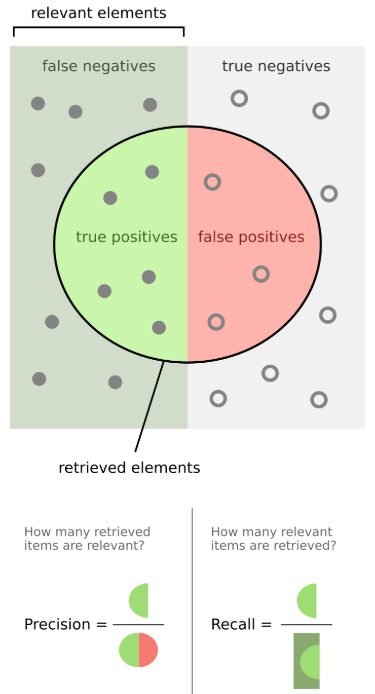

Precision answers the question of how many selected items (within the circle) are relevant. It is a measure of how good the classifier is at selecting True Positives, because it indicates how many of the selected Positives are actually Positives. Recall answers the question of how many relevant items (left rectangle) were selected. It indicates how many instances of all positive instances the classifier can indicate.

A perfect precision equal to 1 means that there are no False Positives. A perfect recall equal to 1 means that there are no False Negatives. But on their own, precision and recall do not provide sufficient information about the quality of the classifier.

Suppose we have a “cautious” classifier that only classifies an item as Positive if it is also really certain that it is a Positive, so that it does not indicate any False Positives, then it will have a precision of 1, but a very low recall because it will probably have many False Negatives.

Conversely, an “unreasonable” classifier that classifies all items as Positive will have a recall of 1 because there are no False Negatives, but its precision will likely be very low because it has many False Positives.

Conclusion: One should consider precision and recall together, with a classifier having both high precision and high recall being a very good classifier.

## F-score

Discussing accuracy, recall, and precision, we have learned that in many cases one metric alone is not sufficient to estimate the performance of a model. The F-score is a metric that combines precision and recall in one metric.

The two example datasets and associated models that we consider in this topic are of course fictional datasets where either false positives or false negatives are a problem. In real problems, there is often no hard preference or at least both are a problem. In the example of the corona test, we obviously do not want to miss any positive cases for the sake of public health, but we also do not want to quarantine too many healthy people because that has economic consequences. In the example of the spam filter, we do not want to label desired emails as spam, but we also do not want an inbox full of spam, because a user will also find that very unpleasant.

### $F_1$ score

What we want is a metric that expresses the balance between precision and recall. A first technique we think of to express such a balance is the *arithmetic mean* of the recall and precision. Unfortunately, in this case we cannot simply use that mean.

Suppose we have a model with 50% recall and 100% precision. The arithmetic mean is 75%. That suggests that we have a decent model. However, we only have 50% recall and that goes against that assumption. Simply taking the arithmetic mean does not work. Why not?

The reason is that both precision and recall are ratios. And you should never simply use the arithmetic mean for ratios. There is a better mechanism for that: the harmonic mean.

**Harmonic mean: example**

To illustrate the harmonic mean and to show that we cannot simply take the average of ratios, we give the following example:

Suppose you have to drive from Vives Kortrijk to Vives Brugge and back. The distance between the two campuses is approximately 50 km. You can drive there at 100 km/h. There is a traffic jam on the return journey and you drive at 50 km/h. The travel times are therefore 30 minutes for the outward journey and 60 minutes for the return journey, and in total you cover the entire route in 90 minutes. The question now is what is the average speed at which you drove?

A naïve solution takes the arithmetic mean: i.e. (100 + 50) / 2 = 75 km/h. This would mean that we drove the entire route of 100 km in 80 minutes, which is clearly not correct! The reason is that we have to take the harmonic mean for ratios.

The harmonic mean $H$ of two numbers $x_1$ and $x_2$ is:

> $\dfrac{1}{H} = \dfrac{1}{2} \big( \dfrac{1}{x_1} + \dfrac{1}{x_2} \big)$

which implies that:

> $H = \dfrac{2x_1x_2}{x_1+x_2}$

The average speed over the two routes is therefore:

> $H = \dfrac{2 * 100 * 50}{100 + 50} = 66.666...$ km/h

The corresponding total travel time at that speed is 90 minutes, and that is correct!

**Harmonic mean of P and R: $F_1$-score**

The harmonic mean of **recall (R)** and **precision (P)** is defined as:

> $F_1 = \dfrac{2PR}{P+R}$

This is the **$F_1$-score**.

If **P** and **R** are equal, then $F_1 = \frac{2PP}{2P} = P = \frac{2RR}{2R} = R$. Just like with the arithmetic mean.

If **P** is much smaller than **R**, or vice versa, then $F_1$ is a small number. Indeed, if P is much smaller than R, then:

> $F_1 \approx \dfrac{2PR}{R} = 2P$

And if R is much smaller than P, then:

> $F_1 \approx \dfrac{2PR}{P} = 2R$

A low $F_1$ score is therefore a warning that at least one value, recall or precision, has a low score itself, and that recall and precision may be out of balance.

Two examples to illustrate the above approximations:

In [11]:
# P << R
P = 0.01
R = 0.9
F1 = 2*P*R/(P+R)
round(F1, 2)

0.02

In [13]:
# R << P
P = 0.99
R = 0.05
F1 = 2*P*R/(P+R)
round(F1, 2)

0.1

$F_1$ is here - rounded to 2 decimal places - indeed equal to 2P and 2R, respectively.

### $F_\beta$-score

The $F_1$-score combines the metrics **precision** and **recall** and treats them equally. In other words, they are given the same weight.

However, we now know that for some models we want to emphasize precision and for others recall. To be able to emphasize this, we generalize the concept of the $F_1$-score to the $F_\beta$-score:

> $F_\beta = \dfrac{(1 + \beta^2)PR}{\beta^2P + R}$

To better understand this formula, we study a few cases.

**Case 1: $\beta=1$**

If $\beta=1$ then we give equal weight to precision P and recall R:

> $F_1 = \dfrac{(1 + 1^2)PR}{1^2P + R} = \dfrac{2PR}{P+R}$

We see that in this case we get the $F_1$-score. Hence the symbol $F_1$.

**Case 2: $\beta=10$**

The formula for $F_\beta$ with $\beta=10$ simplifies to:

> $F_{10} = \dfrac{(1 + 10^2)PR}{10^2P + R} = \dfrac{101PR}{100P + R}$

In this formula you can see that precision P is given 100 times more weight in the denominator than recall R. This means that R will weigh more. *So the larger the value of $\beta$, the more emphasis is placed on recall.* When $\beta^2$ is a large number, the following approximation is indeed valid:

> $F_\beta \approx \dfrac{\beta^2PR}{\beta^2P} = R$

A small example to illustrate this:

In [2]:
P = 0.8
R = 0.5

F1 = 2*P*R/(P+R)
F10 = 101*P*R/(100*P+R)

print('F1 =', round(F1, 2), 'en F10 =', round(F10, 2))

F1 = 0.62 en F10 = 0.5


$F_{10}$ is here - rounded to 2 decimal places - indeed equal to R.

**Case 3: $\beta=0.1$**

The formula for $F_\beta$ with $\beta=0.1$ simplifies to:

> $F_{0.1} = \dfrac{(1 + 0.1^2)PR}{0.1^2P + R} = \dfrac{1.01PR}{0.01P + R}$

In this formula you can see that precision P in the denominator is given 100 times less weight than recall R. This means that P will weigh more. *So the smaller the value of $\beta$, the more the emphasis is on precision.* When $\beta^2$ is a small number, the following approximation is indeed valid:

> $F_\beta \approx \dfrac{PR}{R} = P$


A small example to illustrate this:

In [3]:
P = 0.8
R = 0.5

F1 = 2*P*R/(P+R)
F0_1 = 1.01*P*R/(0.01*P+R)

print('F1 =', round(F1, 2), 'en F0.1 =', round(F0_1, 2))

F1 = 0.62 en F0.1 = 0.8


$F_{0.1}$ is here - rounded to 2 decimal places - indeed equal to P.

**Exercise**

Calculate the $F_{\beta}$ scores for the confusion matrices of the 2 spam filters. Do this for $\beta=0.1$, $\beta=1$ and $\beta=10$.

Discuss your result!

| Spam filter 1 | Predicted spam | Predicted ham | Total |
| --- | --- | --- | --- |
| Spam | 30 | 10 | 40
| Ham | 5 | 55 | 60
| Total | 35 | 65 | 100

| Spam filter 2 | Predicted spam | Predicted ham | Total |
| --- | --- | --- | --- |
| Spam | 35 | 5 | 40
| Ham | 10 | 50 | 60
| Total | 45 | 55 | 100

Solution:

| | P | R
| --- | --- | ---
| filter 1 | 0.857 | 0.75
| filter 2 | 0.777 | 0.875

| $\beta$ | 0.1 | 1 | 10
| --- | --- | --- | ---
| filter 1 | 0.85 | 0.79 | 0.75
| filter 2 | 0.77 | 0.82 | 0.87

## ROC curve

In the previous sections, we defined accuracy, precision, recall, and the $F_{\beta}$ score. We also saw that none of these metrics alone are sufficient, and that evaluating a classification model involves keeping in mind the right balance between different types of errors.

A receiver operating characteristic (ROC) curve is a visual tool that helps us evaluate a model and immediately assess the balance between false positives and false negatives. But to be able to create a ROC curve, we need two more metrics, sensitivity and specificity.

### Sensitivity and specificity

These metrics are mostly used in medical studies, which is why we are referring to 'tests' here.

**Sensitivity**

The ability of a test to correctly identify positively labeled data points is called the **Sensitivity or True Positive Rate (=TPR)**:

> $\textrm{sensitivity} = \frac{\textrm{true positives}}{\textrm{true positives} + \textrm{false negatives}}$

As you can see from the formula, sensitivity is the **recall** as we defined above. It is also called more precisely the **positive recall**.

In the corona model, sensitivity is the number of sick people the test has found compared to the total number of sick people.

In the spam example, sensitivity is the number of spam emails the filter has found compared to the total number of spam emails.

**Specificity**

The ability of a test to correctly identify negatively labeled data points is called the **Specificity or True Negative Rate (=TNR)**:

> $\textrm{specificity} = \frac{\textrm{true negatives}}{\textrm{true negatives} + \textrm{false positives}}$

This metric is completely new, and is sometimes also called **negative recall**. Note that the formula for specificity is obtained by switching 'positives' and 'negatives' in the formula for sensitivity.

In the corona model, specificity is the number of healthy people the test found compared to the total number of healthy people.

In the spam example, specificity is the number of ham mails the filter found compared to the total number of ham mails.

It should be clear that we want a model with high sensitivity for the corona test, and that we want a test with high specificity for the spam filter!

**Example**

To clarify these concepts, we repeat the figure given above:

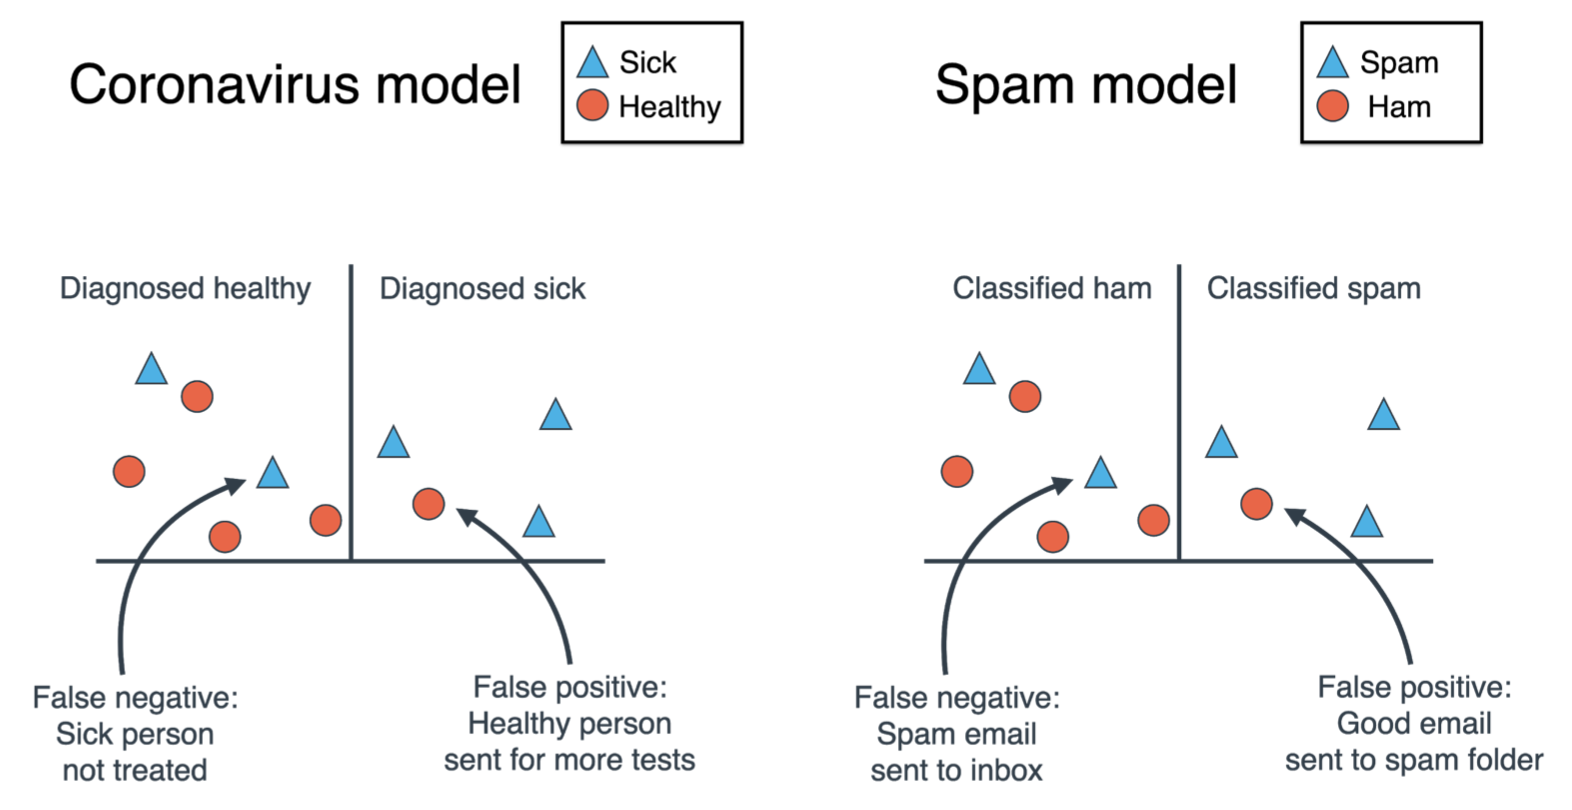

The following counts apply to both models:
- 3 true positives
- 4 true negatives
- 1 false positive
- 2 false negatives

> $\textrm{sensitivity} = \frac{\textrm{true positives}}{\textrm{true positives} + \textrm{false negatives}} = \frac{3}{3+2} = 0.6 = 60\%$

> $\textrm{specificity} = \frac{\textrm{true negatives}}{\textrm{true negatives} + \textrm{false positives}} = \frac{4}{4+1} = 0.8 = 80\%$

**False Positive Rate and False Negative Rate**

Analogous to the true positive rate (sensitivity), you can also define the **false positive rate (= FPR)**:

> $\textrm{false positive rate} = \frac{\textrm{false positives}}{\textrm{false positives} + \textrm{true negatives}}$

So for the above model we get:

> $\textrm{FPR} = \frac{\textrm{FP}}{\textrm{FP} + \textrm{TN}} = \frac{1}{1 + 4} = 0.20 = 20\%$

Note that the false positive rate is equal to (1 - specificity), or:

> $\textrm{FPR} = 1 - \textrm{TNR}$

And for the sake of completeness, we also provide the definition of the **false negative rate (= FNR)**:

> $\textrm{false negative rate} = \frac{\textrm{false negatives}}{\textrm{false negatives} + \textrm{true positives}}$

So for the above model we get:

> $\textrm{FNR} = \frac{\textrm{FN}}{\textrm{FN} + \textrm{TP}} = \frac{2}{2 + 3} = 0.40 = 40\%$

And here too it holds that:

> $\textrm{FNR} = 1 - \textrm{TPR}$

**Exercise**

Calculate the metrics sensitivity, specificity, false positive rate and false negative rate for the confusion matrices of the 2 spam filters.

Discuss your results!

| Spam filter 1 | Predicted spam | Predicted ham | Total |
| --- | --- | --- | --- |
| Spam | 30 | 10 | 40
| Ham | 5 | 55 | 60
| Total | 35 | 65 | 100

| Spam filter 2 | Predicted spam | Predicted ham | Total |
| --- | --- | --- | --- |
| Spam | 35 | 5 | 40
| Ham | 10 | 50 | 60
| Total | 45 | 55 | 100

Solution:

| | TPR | TNR | FPR | FNR |
| --- | --- | --- | --- | --- |
| filter 1 | 0.75 | 0.92 | 0.08 | 0.25|
| filter 2 | 0.875 | 0.83 | 0.17 | 0.125|

**Metrics and confusion matrix**

To remember how to calculate the different metrics, we can "visualize" them using the confusion matrix:

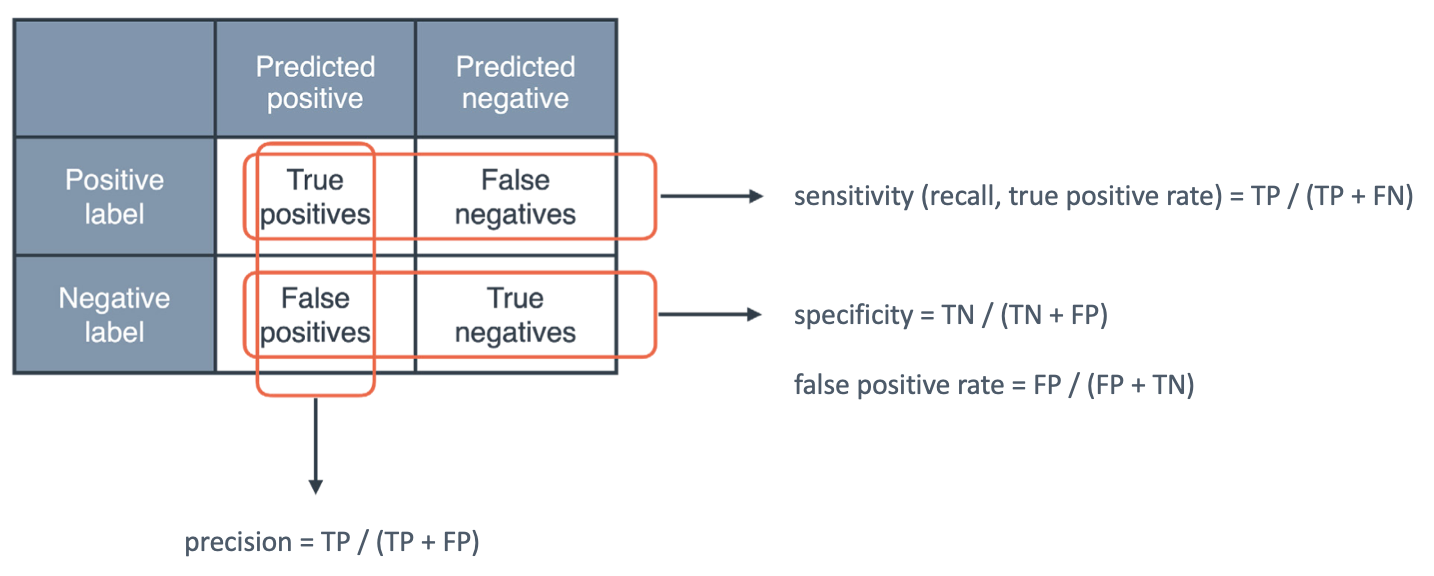

### Creating the ROC curve

Now that we know what sensitivity and specificity are, we can construct the ROC curve. In this section, we will discuss constructing the ROC curve step by step, and we will explain how to interpret it. The machine learning model on which we will build our reasoning is logistic regression for binary classification. This [StatQuest video](https://youtu.be/4jRBRDbJemM?si=zpgGRXTOd_z0-dkc) also clearly explains how to create a ROC curve.

As seen in the previous topic, the output of a logistic regression model is the probability that a data point belongs to the positive class, and a threshold of 0.5 was chosen for the final decision: if the probability is greater than or equal to 0.5, we give a positive label (the data point belongs to the "True" class), for a probability smaller than 0.5 we predict a negative label (the data point does not belong to the "True" class but to the "False" class).

But of course we could have chosen a smaller or larger threshold. With the ROC curve we can visually check which threshold yields the 'best' binary classification.

**Influence of the threshold**

The value at which we set the threshold is a choice that we as machine learning experts have to make ourselves. For our example, let's set the threshold at 0.2, 0.5 and 0.8. The result is visualized in the figure below.

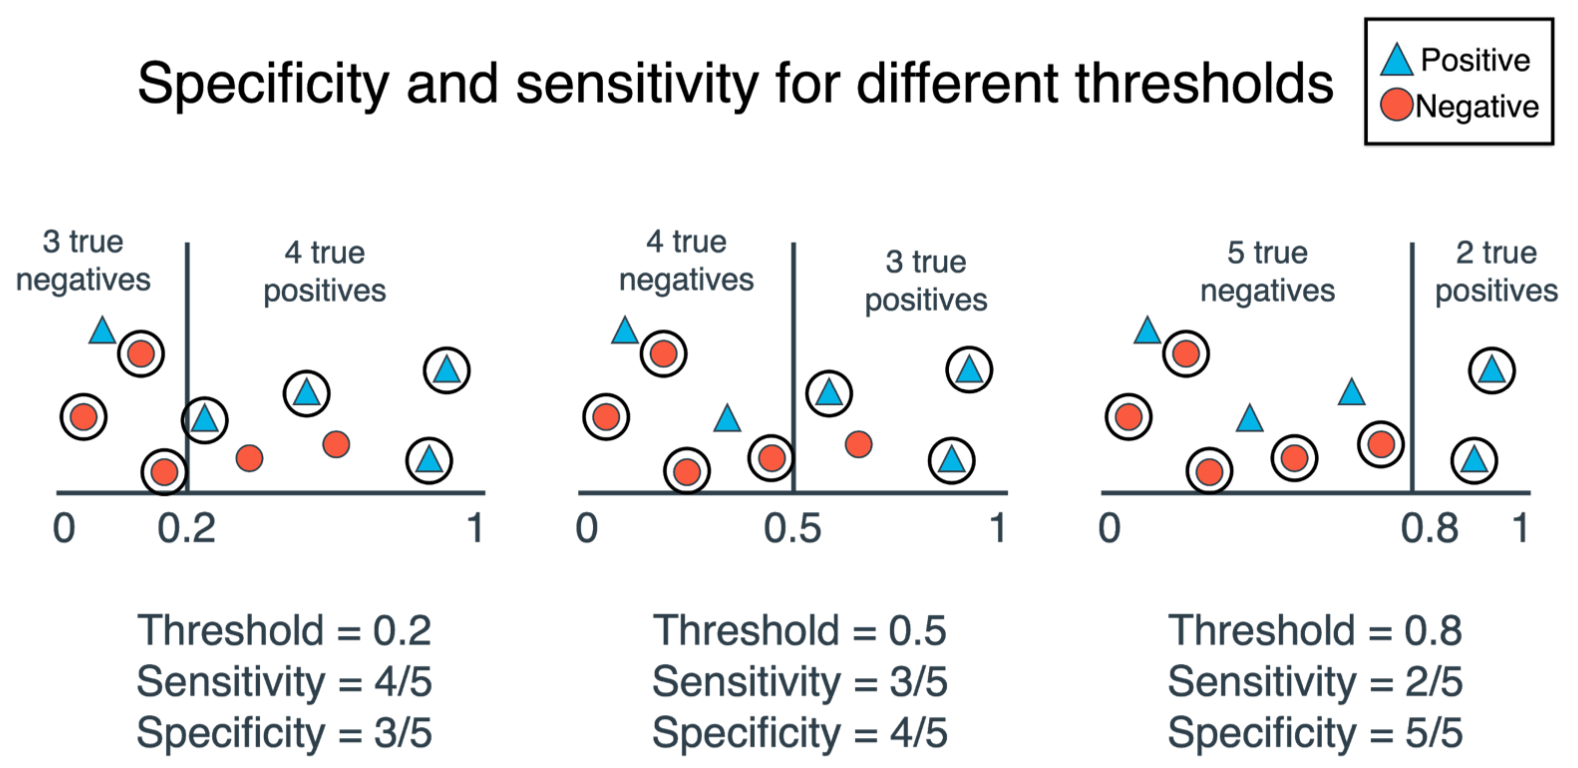

For each threshold level we now calculate the sensitivity, specificity and the false positive rate.

|  | Threshold 0.2 | Threshold 0.5 | Threshold 0.8 |
| --- | --- | --- | --- |
| TP | 4 | 3 | 2 | TN | 3 | 4 | 5 | FP | 2 | 1 | 0 | FN | 1 | 2 | 3 | Sensitivity | 80% | 60% | 40% | Specificity | 60% | 80% | 100% | False positive rate | 40% | 20% | 0%

As you can see:
- the lower the threshold, the higher the sensitivity
- the higher the threshold, the higher the specificity
- the higher the threshold, the lower the false positive rate

By varying that threshold, you can influence the balance between sensitivity and specificity.

**ROC curve**

To construct the ROC curve, we vary the threshold from 0 to 1, in small steps. For example, as in the table below:

|step|threshold|true positives|false negatives|true negatives|false positives|control|sensitivity|specificity|false positive rate|accuracy
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | ---
|0|0|5|0|0|5|10|1|0|1|0.5
|1|0.1|5|0|1|4|10|1|0.2|0.8|0.6
|2|0.2|4|1|1|4|10|0.8|0.2|0.8|0.5
|3|0.3|4|1|2|3|10|0.8|0.4|0.6|0.6
|4|0.4|4|1|3|2|10|0.8|0.6|0.4|0.7
|5|0.5|3|2|3 |2|10|0.6|0.6|0.4|0.6
|6|0.6|3|2|4|1|10|0.6|0.8|0.2|0.7
|7|0.7|2|3|4|1|10|0.4|0.8|0.2|0.6
|8|0.8|2|3|5|0|10|0.4|1|0|0.7
|9|0.9|1|4|5|0|10|0.2|1|0|0.6
|10|1|0|5|5|0|10|0|1|0|0.5

Next, for the different possible values of the threshold, we want to evaluate the balance between sensitivity and specificity. However, the ROC curve plots the true positive rate (or sensitivity) versus the false positive rate, which is equal to 1 minus the specificity:

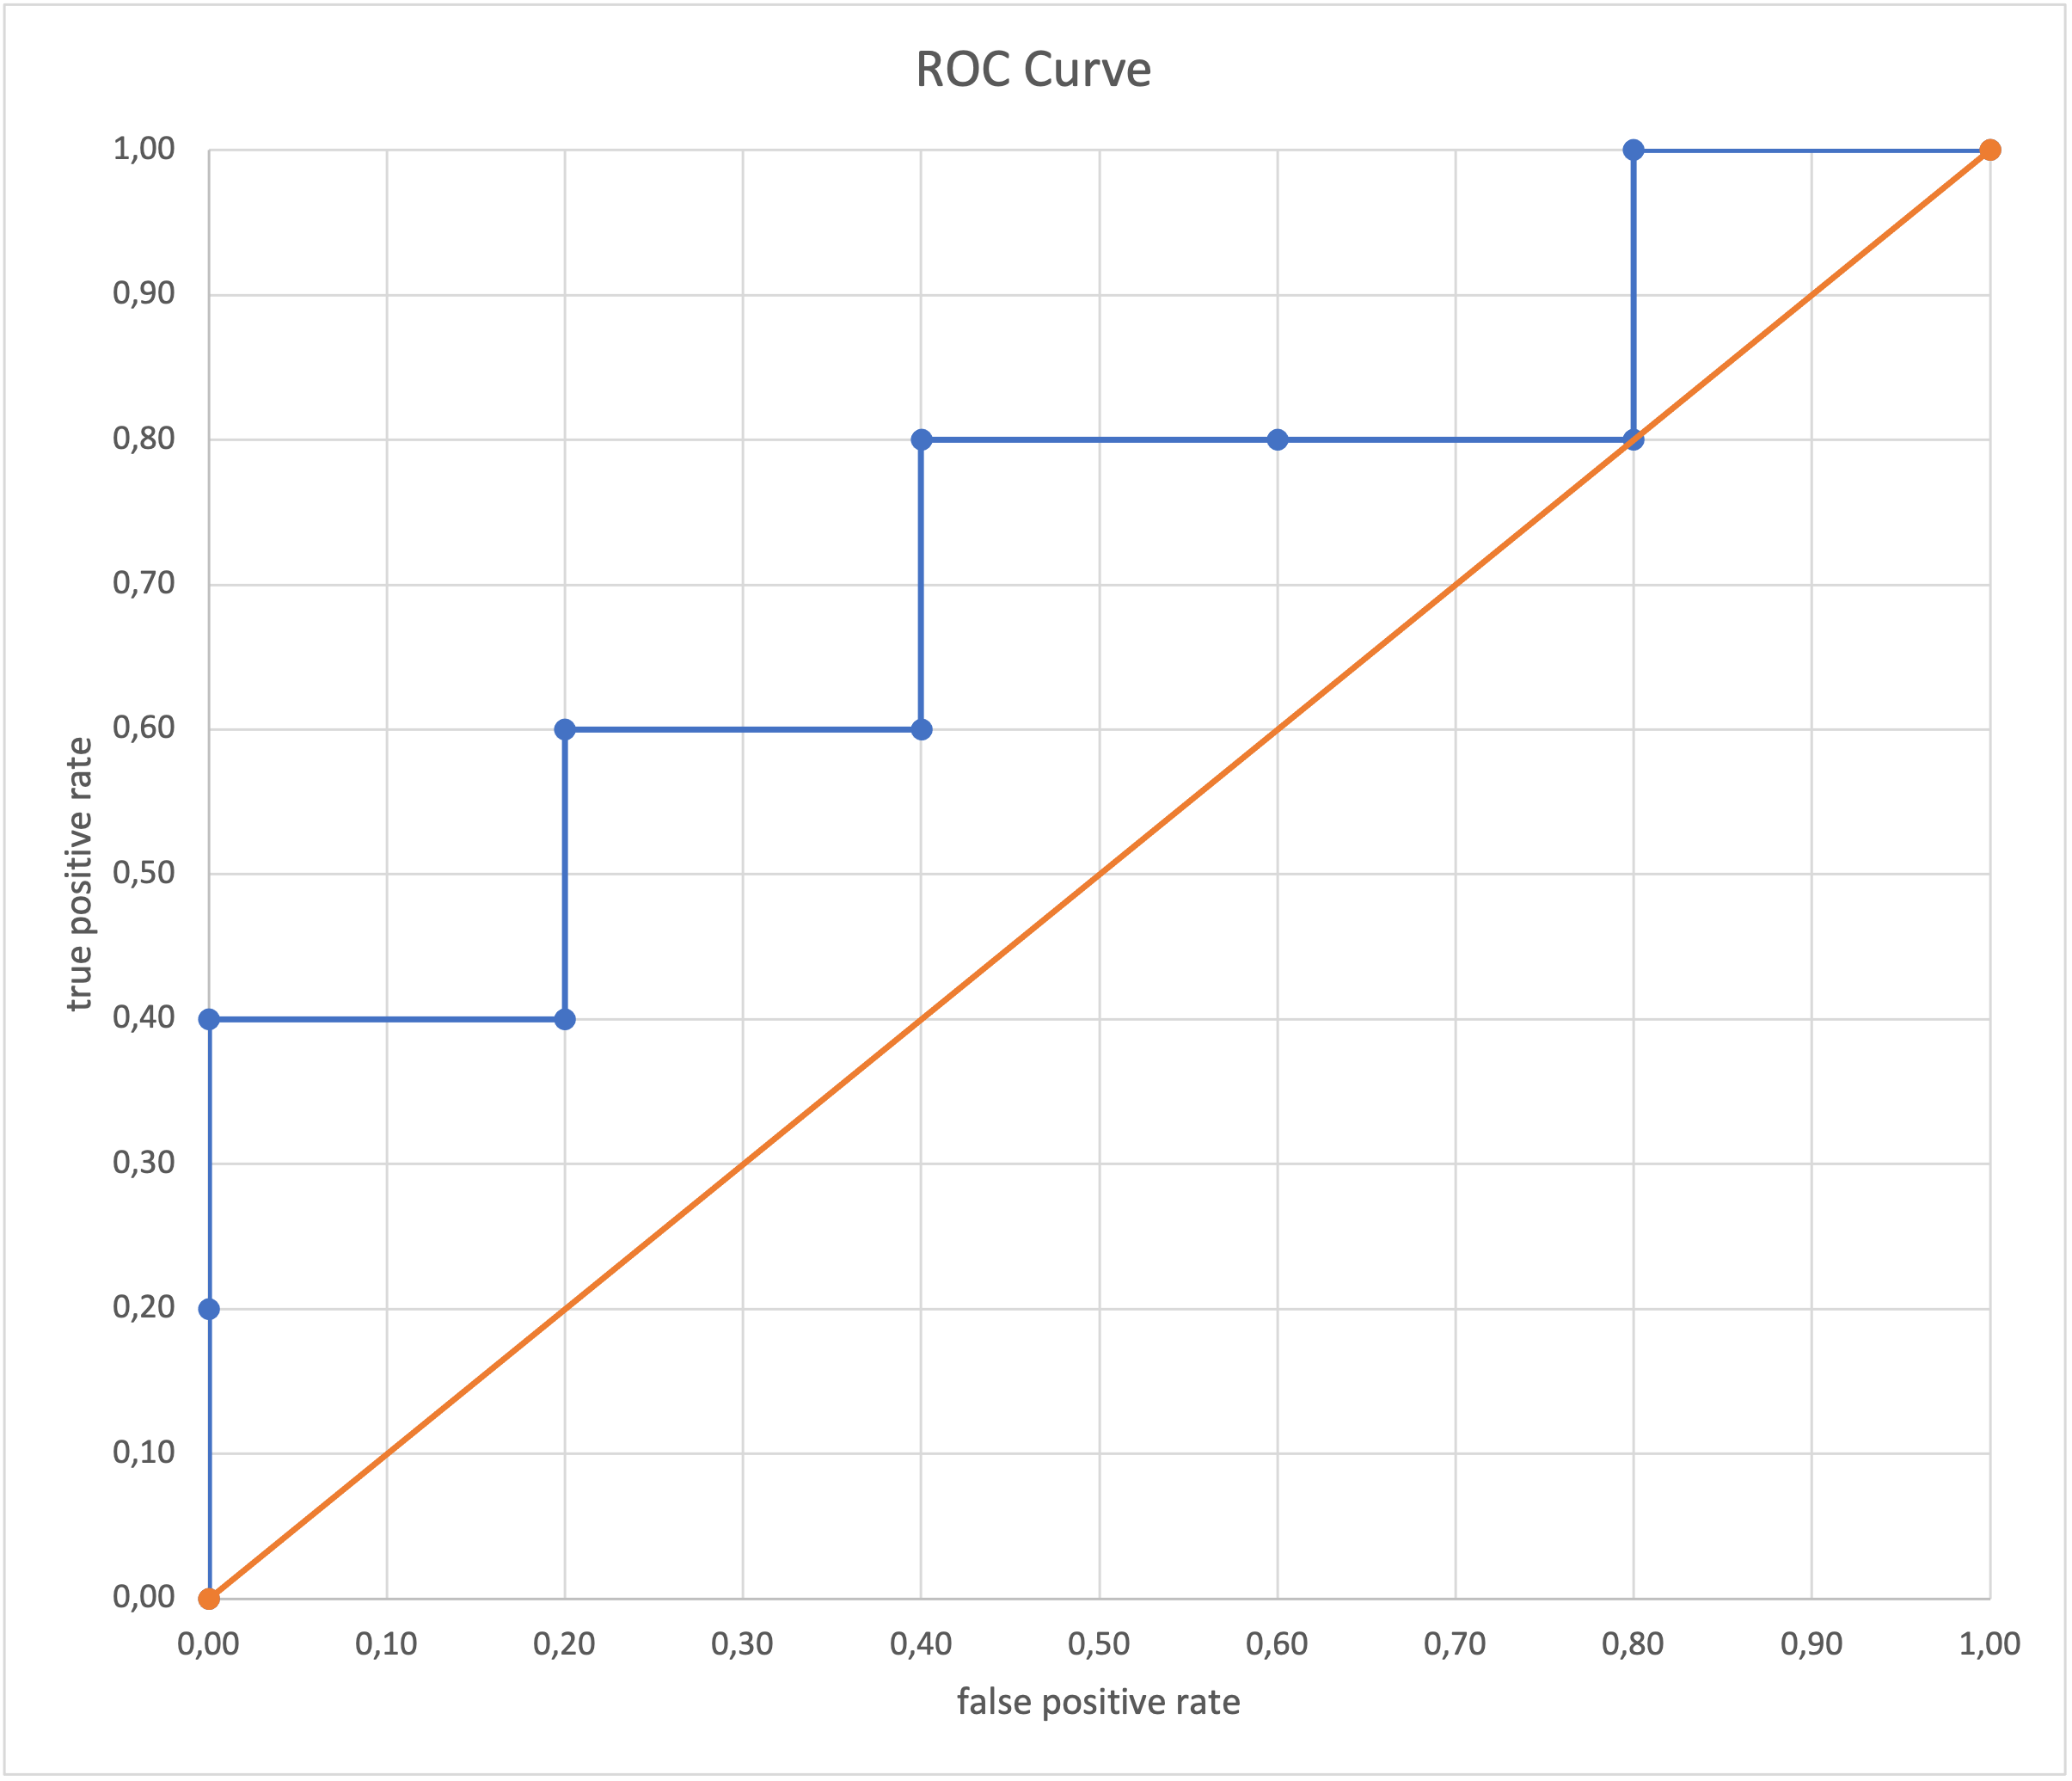

The orange diagonal represents thresholds where the true positive rate and the false positive rate are almost equal. The model does no better than guessing. A data point has an equal probability of being labeled positive or negative.

Since the true positive rate and false positive rate are equal on the orange diagonal, the orange diagonal represents thresholds where the accuracy is equal to 50%.

Points with the highest accuracy on the blue curve are the furthest from the orange diagonal. In the figure above, there are three such points. The model cannot do better in accuracy than those three points.

**Select Threshold**

The relationship between choosing a threshold and the influence on sensitivity and specificity is nicely summarized in the following figure:

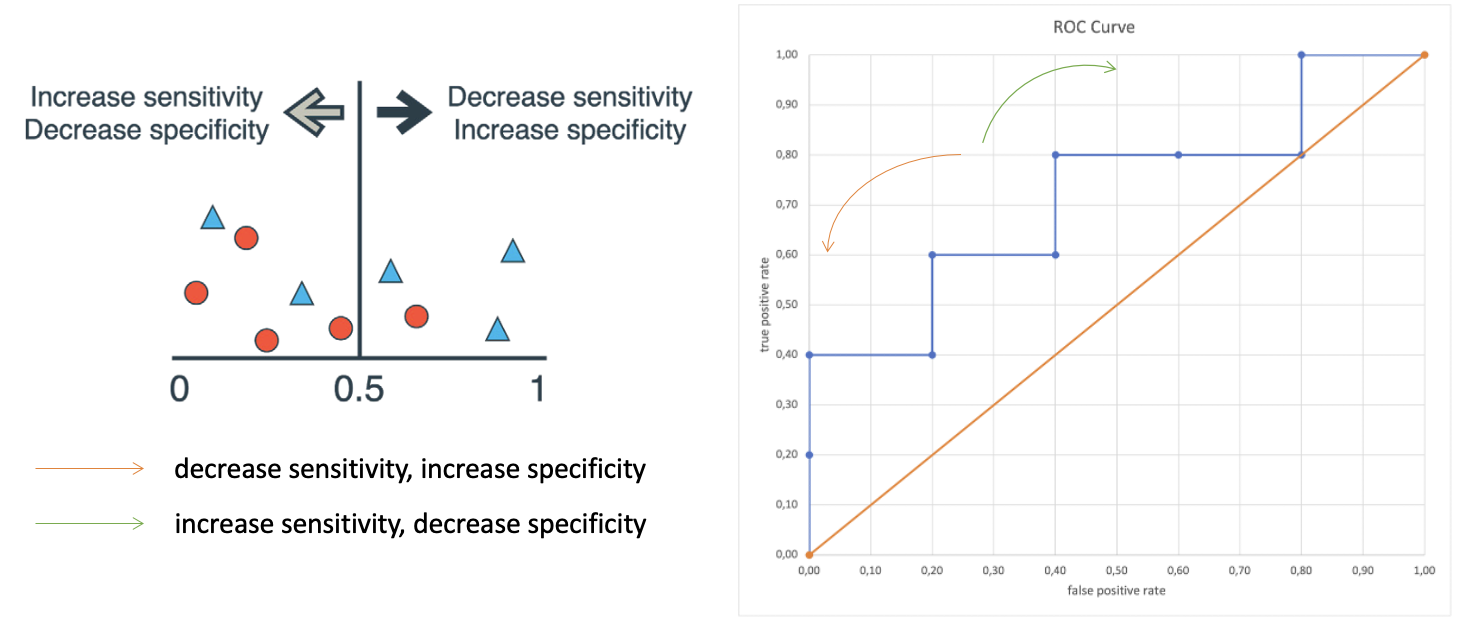

It is best to select the point that guarantees the best balance between sensitivity and specificity for the specific application you are designing. If necessary a point can be chosen with a lower accuracy than the optimal accuracy.

### Area Under Curve

On a ROC curve we can read an important metric, the Area Under Curve (AUC), which can give us an indication of the quality of a classification model. The AUC is the area on the curve under the blue line. In the case of the curves in this topic, the AUC is the number of squares under the blue line out of 100.

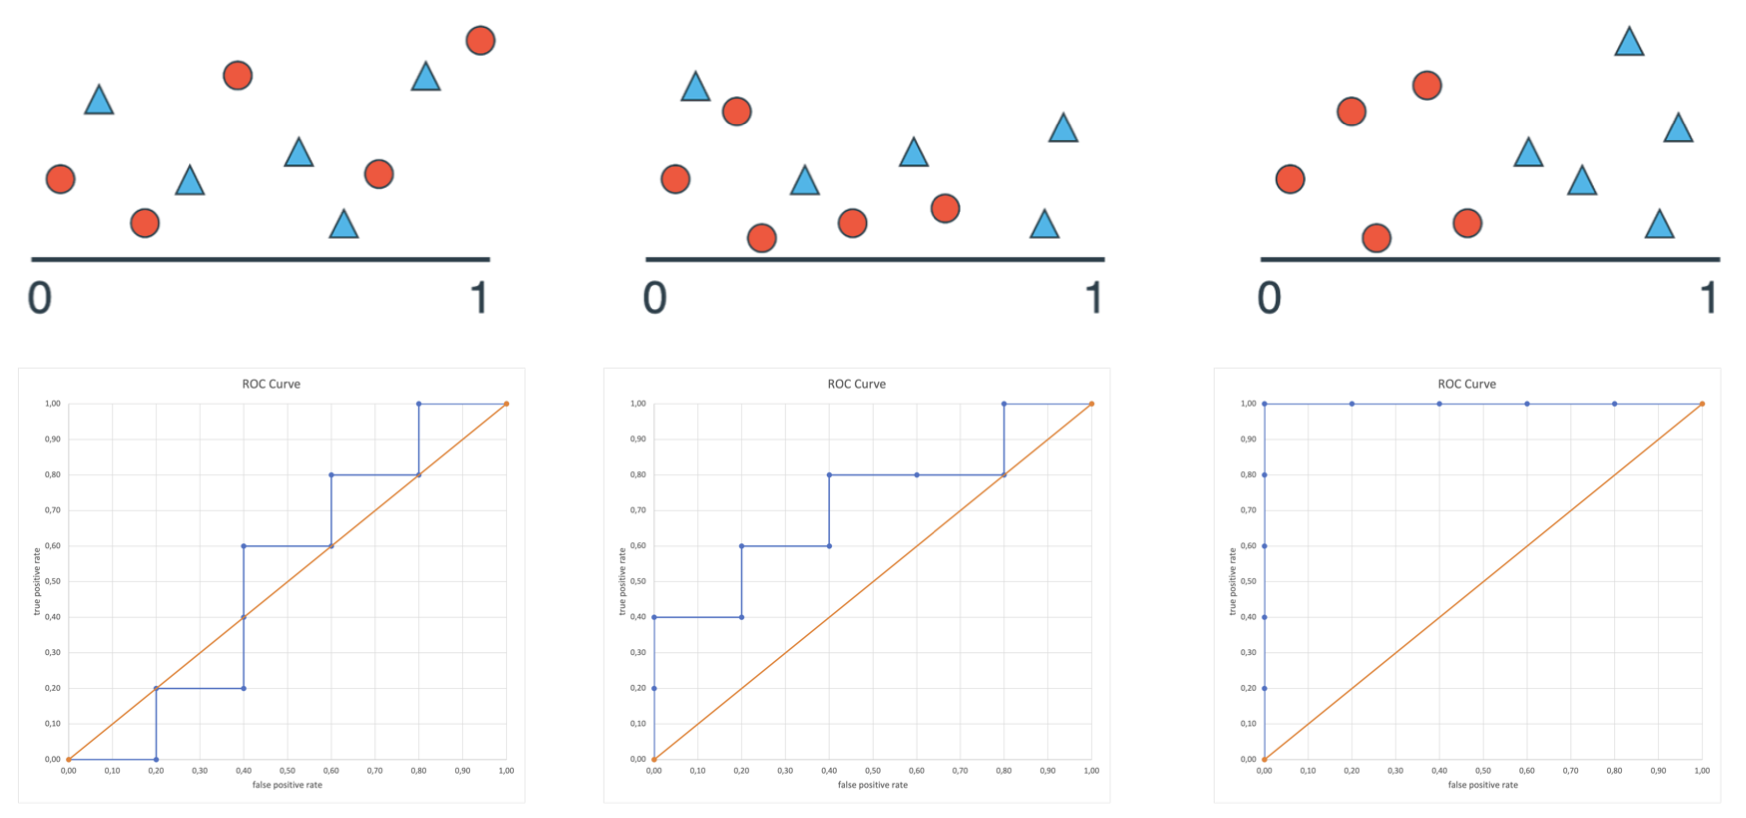

The AUC for the three models above is:

- 52/100 = 0.52
- 72/100 = 0.72
- 100/100 = 1.00

The first model has an AUC of 0.52, and you can see that the blue line is indeed quite close to the orange diagonal. The orange diagonal represents thresholds where the true positive rate and the false positive rate are equal. So the model does no better than guessing. A data point has an equal probability of being labeled positive or negative. So we want a curve that is further away from the diagonal, as in the second model. The third model is a model that can classify the given data perfectly.

**General**

The shape of the ROC curve therefore depends on "how far" the classes are apart,
and how "good" the applied classifier is. In other words, the curve shows how "well" a model succeeds in separating the
two classes from each other. With a **perfect classifier** the AUC area is equal to 1. In the case of a perfect model we can schematically represent the situation as follows:

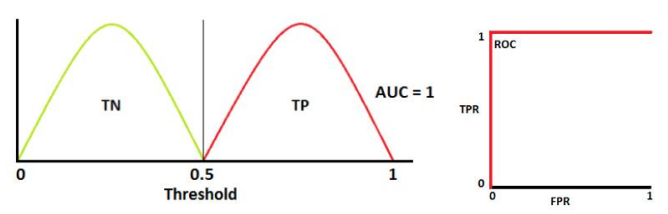

All green data points (TN) were also classified as green, and all red (TP) as red.

The diagram below
shows a more realistic situation where AUC is equal to 0.7, which means that there is
a 70% probability that the model is able to distinguish the red (TP) from the green (TN) data points:

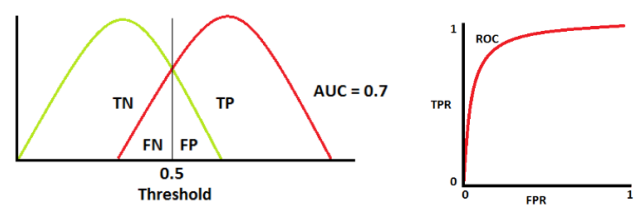

The worst case is when the AUC is 0.5, which means that the model is not able to distinguish the two classes. In that case we speak of a **random classifier**:

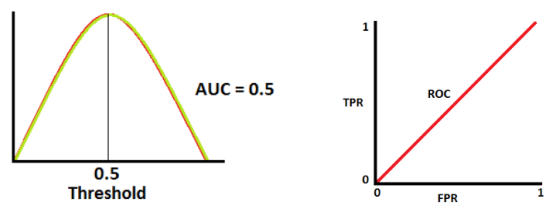

When the AUC is zero, all green data points are labeled as red, and all red data points are labeled as green. You could say this is a **"reverse" classifier**. In any case, if we simply reverse the prediction in this case, we have a perfect model again:

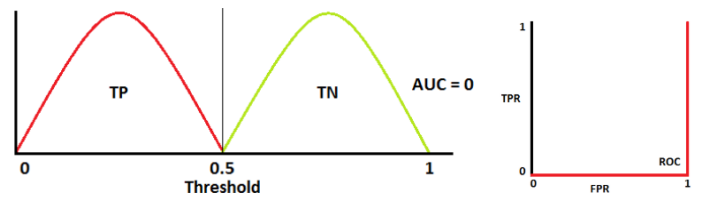

So there are two important aspects here:

1. First and foremost, there is the **intrinsic quality of the classifier**. By this we mean how well the classifier maps the Positives to 1, and the Negatives to 0. The AUC is a measure of the separating or discriminative power of the classifier, where a high AUC
means that this power is high.

2. A second aspect is **the choice of the threshold**. The curve itself is determined by the classifier, but the choice of the threshold determines where on the curve we are. In other words, the TPR vs. FPR trade-off is determined by the threshold, because a high TPR, which is good, very often implies a low FPR, which is bad, while a high FPR, which is good, implies a low TPR, which is bad.

In this way, we can distinguish certain cases on the ROC curve, as we have done below.
- We have already mentioned case D as the **"perfect" classifier** with TPR = 1 and FPR = 0.
- We have called case C on the diagonal the random or **"arbitrary" classifier** where TPR = FPR. This classifier guesses, as it were, and will select an incorrect value for every correct value.
- The **"inverted" classifier** E is the classifier that predicts more incorrectly than correctly.
- If we then compare A with B, then A is
a **"cautious" classifier** that makes fewer errors, but also has fewer correct ones than B.
- In the
extreme case, we have in the origin (0, 0) the **"cowardly" classifier**, which makes no errors, but
therefore also does not label any values ​​correctly.
- At point (1, 1) there is the **"blind" classifier**, which marks all values ​​as Positives.

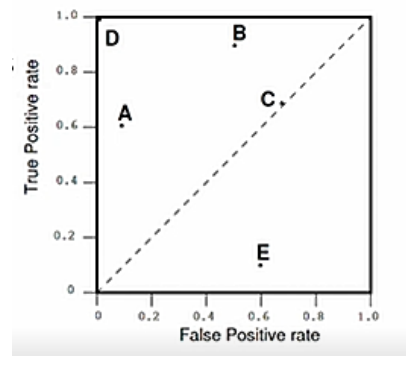

Although the choice of the threshold, or thus the point on the ROC curve, is problem-dependent, as we explained above, we can nevertheless state with this explanation in mind that we will usually choose the point that is closest to the "perfect" classifier. That is the point (0, 1) at the top left of the graph. In the figure below, the point on the ROC curve that is closest to that point has indeed been chosen:

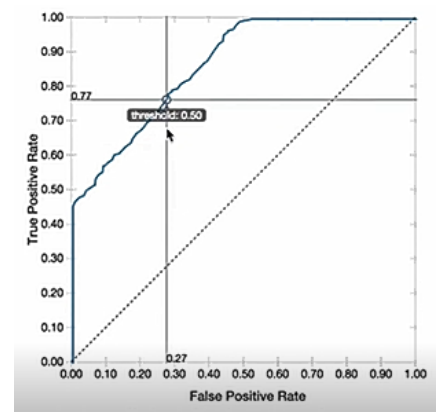

## Scikit-Learn

Now let's illustrate all this theory with an example. We read in the fictional dataset "insurance.json" as a Pandas dataframe:

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100 # make figures a bit larger

In [19]:
df = pd.read_json("insurance.json", orient="table")
df.head()

,age,salary,risk
0,47.0,2304.0,low
1,38.0,2388.0,low
2,42.0,2059.0,low
3,49.0,2191.0,low
4,47.0,2222.0,low


The dataset divides insurance customers into 'high' or 'low' risk, looking at 'age' and monthly 'salary'. The latter two are our features, and 'risk' is the target containing the labels. Let's make a scatterplot, where we indicate the people with 'low' risk in green, and those with a 'high' risk in red:

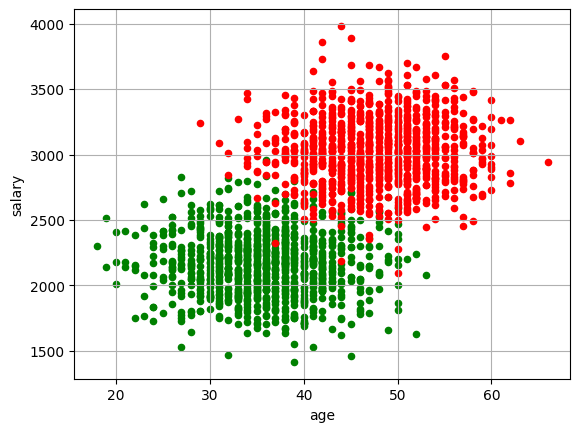

In [20]:
_, ax = plt.subplots()
df[df.risk=='low'].plot.scatter(x='age', y='salary', c='g', ax=ax);
df[df.risk=='high'].plot.scatter(x='age', y='salary', c='r', ax=ax);
ax.grid()

The two classes are separable. We will apply **logistic regression** for this. Normally we have to split the dataset, but since this is an example, we will take the entire dataset.

In [29]:
from sklearn.linear_model import LogisticRegression

X = df.loc[:, ['age', 'salary']]
y = (df.risk=='low').astype(int)
lr = LogisticRegression(penalty=None) # no regularization
lr.fit(X, y)

LogisticRegression(penalty=None)

We redraw the scatter plot and add the separating line:

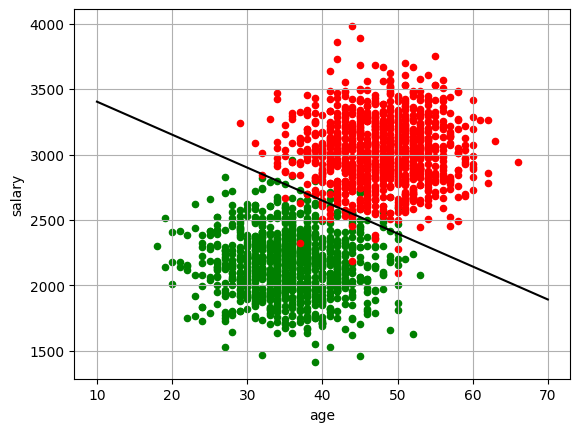

In [25]:
a, b = lr.coef_[0], lr.intercept_[0] # parameters
x_line = np.array([10, 70])
y_line = -(x_line * a[0] + b) / a[1]

_, ax = plt.subplots()
df[df.risk=='low'].plot.scatter(x='age', y='salary', c='g', ax=ax);
df[df.risk=='high'].plot.scatter(x='age', y='salary', c='r', ax=ax);
ax.grid()
ax.plot(x_line, y_line, 'k-');

Now, we will use Scikit-Learn functions from the module `sklearn.metrics` to evaluate the model. Let us first look at the **confusion matrix**. For that we obviously need to calculate the predictions.

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
yp = lr.predict(X) # predictions
print(confusion_matrix(y_true=y, y_pred=yp))

[[980  20]
 [ 22 978]]


We can also plot the confusion matrix. By setting the input parameter `normalize` to `"true"` (a string!) we get percentages instead of numbers. This value should not be interpreted as a boolean, because it refers to the "true values" (see below). You can now also see that Scikit-Learn uses the rows for the labels and the columns for the predictions.

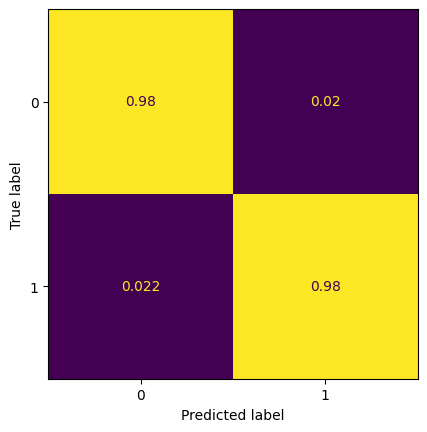

In [27]:
ConfusionMatrixDisplay.from_predictions(y_true=y, y_pred=yp, normalize='true', colorbar=False);

Accuracy, recall, precision, $F_1$ and $F_\beta$ scores are also available in the `metrics` module.

In [28]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, fbeta_score

for metric in [accuracy_score, recall_score, precision_score, f1_score]:
    score = metric(y_true=y, y_pred=yp)
    print(f"{metric.__name__} = {score:.5f}")
print(f"fbeta_score (beta=2.0) = {fbeta_score(y, yp, beta=2.0):.5f}")
print(f"fbeta_score (beta=0.5) = {fbeta_score(y, yp, beta=0.5):.5f}")

accuracy_score = 0.97900
recall_score = 0.97800
precision_score = 0.97996
f1_score = 0.97898
fbeta_score (beta=2.0) = 0.97839
fbeta_score (beta=0.5) = 0.97957


Note that our `LogisticRegression` object also has a `score` method that returns the accuracy:

In [ ]:
lr.score(X, y)

0.979

It is also useful to print a **classification report**:

In [30]:
from sklearn.metrics import classification_report
print(classification_report(y, yp))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1000
           1       0.98      0.98      0.98      1000

    accuracy                           0.98      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.98      0.98      0.98      2000



To construct **the ROC curve** and calculate the associated AUC, we don't need the predictions, but the probabilities! We calculate these with the method `predict_proba` of class `LogisticRegression`.

In [31]:
p = lr.predict_proba(X)
p

array([[7.84452591e-02, 9.21554741e-01],
       [1.03917819e-02, 9.89608218e-01],
       [3.68413977e-04, 9.99631586e-01],
       ...,
       [9.99692402e-01, 3.07597534e-04],
       [9.99992254e-01, 7.74644200e-06],
       [9.96295851e-01, 3.70414900e-03]])

The left column gives the probabilities of label `1`, the right column the probabilities of label `0`. Of course the sum of both equals 1. For the ROC curve we need the 2nd column!

AUC = 0.998


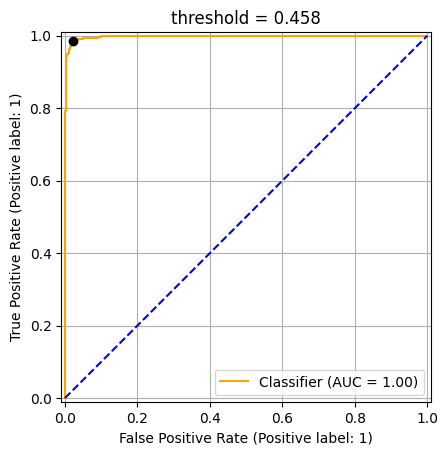

In [32]:
from sklearn.metrics import roc_auc_score, roc_curve, RocCurveDisplay

# Calculate AUC
print(f"AUC = {roc_auc_score(y_true=y, y_score=p[:, 1]):.3f}") # Take 2nd column of p!

# Plot ROC curve using probabilities
RocCurveDisplay.from_predictions(y, p[:, 1], c='orange')
plt.plot([0, 1], [0, 1], 'b--'); # diagonal
plt.grid();

# find closest point of (0, 1) and add to plot
fpr, tpr, thresholds = roc_curve(y, p[:, 1], drop_intermediate=False) # fpr and tpr for different thresholds
closest = np.argmin(fpr**2 + (tpr - 1)**2) # closest point to (0, 1)
plt.plot(fpr[closest], tpr[closest], "ko");
plt.title(f"threshold = {thresholds[closest]:.3f}"); # threshold of closest point

We calculate the AUC separately with `roc_auc_score` just like we calculated the other metrics. With `RocCurveDisplay.from_predictions` we plot the ROC curve. We determine the point on that curve closest to the perfect classifier (0, 1) using the Euclidean distance. The optimal threshold belongs to that point, which is 0.458 here. We get the different thresholds and corresponding FPR and TPR from the function `roc_curve`. Alternatively, we could use the arrays that this function returns to plot the ROC curve:

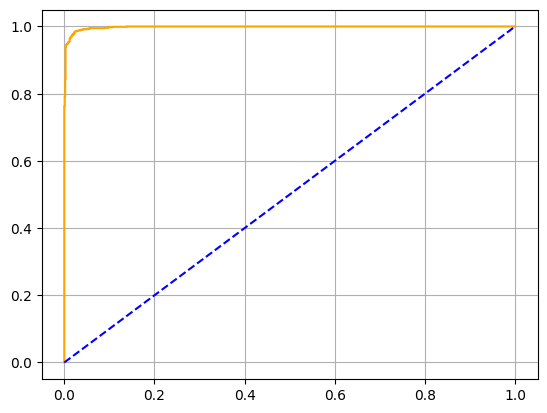

In [33]:
plt.plot(fpr, tpr, c='orange');
plt.plot([0, 1], [0, 1], 'b--');
plt.grid()

### Plotting confusion matrices

In this section we will briefly discuss plotting confusion matrices. We will show you how to easily create a confusion matrix using labels and predictions using the `sklearn` class `ConfusionMatrixDisplay`.

In [34]:
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay

We randomly create labels and predictions:

In [36]:
y = np.hstack(( np.zeros(10), np.ones(10), 2 * np.ones(10) ))
y

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.])

In [37]:
yp = y.copy()
np.random.seed(0)
np.random.shuffle(yp)
yp

array([0., 2., 1., 1., 2., 2., 2., 1., 1., 2., 0., 1., 0., 1., 2., 2., 0.,
       2., 0., 0., 1., 1., 0., 0., 2., 0., 0., 2., 1., 1.])

With static method `from_predictions` we can easily plot the confusion matrix:

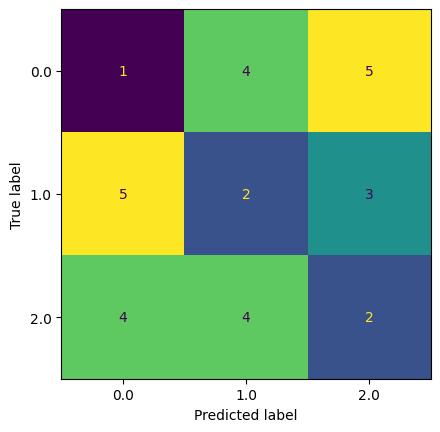

In [38]:
ConfusionMatrixDisplay.from_predictions(y_true=y, y_pred=yp, colorbar=False);

We can also display percentages in the confusion matrix by setting input argument `normalize` to `'all'`:

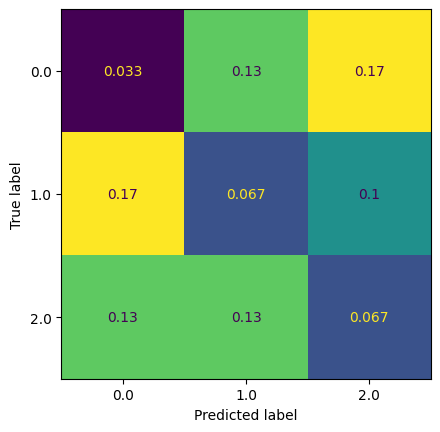

In [39]:
ConfusionMatrixDisplay.from_predictions(y_true=y, y_pred=yp,
                                        normalize='all',  # all = normalize values ​​based on total
                                        colorbar=False);  # no colorbar

If we want to normalize based on the row totals, we have to set `normalize` to `'true'`. String `'true'` refers to the 'true' labels and should not be interpreted as boolean `True`!

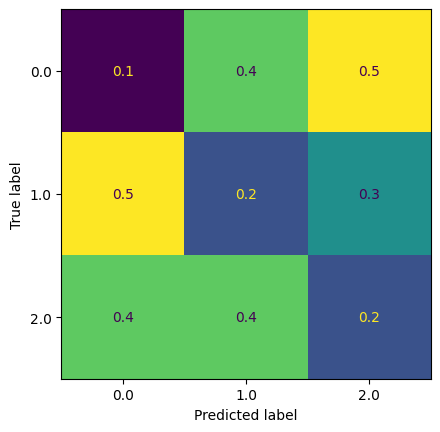

In [40]:
ConfusionMatrixDisplay.from_predictions(y_true=y, y_pred=yp,
                                        normalize='true',  # true values ​​= normalize rows
                                        colorbar=False);

If you want to normalize based on the column totals, set `normalize` to `'pred'`, which is short for 'predicted':

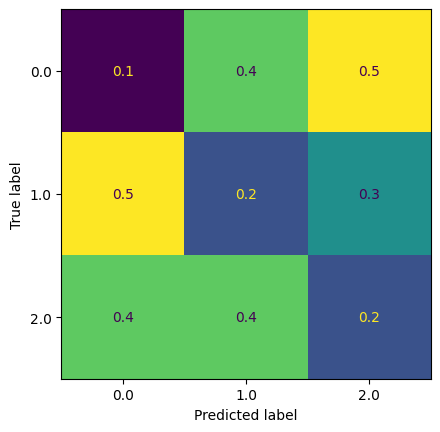

In [41]:
ConfusionMatrixDisplay.from_predictions(y_true=y, y_pred=yp,
                                        normalize='pred', # predicted values ​​= normalize columns
                                        colorbar=False);

The `ConfusionMatrixDisplay` class also has a static method `from_estimator` that allows you to plot a confusion matrix based on the model (= the estimator) and the features and labels:

> `ConfusionMatrixDisplay.from_estimator(model, X, y, ...)`

The optional input parameters `normalize` and `colorbar` are of course also available with this method. The advantage of this method is that you don't have to calculate the predictions first.

---

---
## SOURCES
* Textbook: Grokking Machine Learning (version 12), Manning Early Access Program, by Luis G. Serrano, 2020.
* Chapter "Evaluation Metrics" of the Data Science II Course, Professional Bachelor's Degree in Applied Computer Science, Karel de Grote Hogeschool, academic year 2019-2020, taught by Wouter Deketelaere.
* https://nl.wikipedia.org/wiki/Afstand_(wiskunde)
* https://en.wikipedia.org/wiki/Precision_and_recall
* https://towardsdatascience.com/understanding-auc-roc-curve-68b2303cc9c5
* https://scikit-learn.org/stable/modules/model_evaluation.html

---